# Jump-Point Embedding — Time-Aware Transformer (32 / 64 / 128 dim)

**Data**: `jump_features_millisec.csv` — pressure & flow jump points  
**Pipeline**:
```
CSV (pressure + flow jump points)
  → Filter test_type (pressure & flow only)
  → Crop to last 7 days per patient (end_date = last recorded timestamp)
  → Official train/val/test split (df_split.csv)
  → Encode test_type  → Scale test_value
  → Scale raw timestamp → Time2Vec(timestamp_scaled)
  → Shared Transformer Encoder  (BCE loss, patient-level label)
  → chunk embedding → mean-pool → 1 embedding per patient
  → Save emb_train/val/test.parquet
     named: ..._32dim_withtime_jumppoint
             ..._64dim_withtime_jumppoint
             ..._128dim_withtime_jumppoint
```

---
## Step 1 — Install & Import

In [1]:
!pip install -q xgboost scikit-learn

In [2]:
import os
import gc
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import GradScaler, autocast
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


---
## Step 2 — Mount Drive & Load CSV

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_AI    = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI"
CSV_PATH   = os.path.join(BASE_AI, "jump_point_model/full30days/jump_point_data/jump_features_millisec.csv")
SPLIT_PATH = os.path.join(BASE_AI, "train_val_test_split/df_split.csv")
BASE_SAVE  = os.path.join(BASE_AI, "Best_Model")

df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'test_type values: {df["test_type"].unique()}')
df.head(3)

Mounted at /content/drive
Loaded: (3139077, 6)
Columns: ['patient_id', 'label', 'timestamp', 'test_type', 'test_value', 'timestamp_millisec']
test_type values: ['resrate' 'minutevent' 'tidalvolume' 'leak' 'flow' 'pressure' 'spo2']


,patient_id,label,timestamp,test_type,test_value,timestamp_millisec
0,1,0,2023-10-02 01:04:45,resrate,0.0,2023-10-02 01:04:45.000
1,1,0,2023-10-02 01:04:45,minutevent,0.0,2023-10-02 01:04:45.000
2,1,0,2023-10-02 01:04:46,resrate,26.0,2023-10-02 01:04:46.000


---
## Step 3 — Filter (pressure & flow only) + Parse Timestamp

In [4]:
# Keep only pressure and flow, use millisec timestamp, drop old timestamp
df = df[df['test_type'].isin(['pressure', 'flow'])].copy()
df = df.drop(columns=['timestamp'])
df = df.rename(columns={'timestamp_millisec': 'timestamp'})
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp']).reset_index(drop=True)

print(f'After filter: {df.shape}')
print(df['test_type'].value_counts())
print(f'\nPatients : {df["patient_id"].nunique()}')
print(f'Label 0  : {df.drop_duplicates("patient_id").query("label==0").shape[0]}')
print(f'Label 1  : {df.drop_duplicates("patient_id").query("label==1").shape[0]}')
df.head(3)

After filter: (2834784, 5)
test_type
pressure    2453333
flow         381451
Name: count, dtype: int64

Patients : 85
Label 0  : 56
Label 1  : 29


,patient_id,label,test_type,test_value,timestamp
0,1,0,flow,82.699997,2023-10-02 03:36:04.200
1,1,0,flow,-33.400002,2023-10-02 03:36:05.200
2,1,0,flow,96.699997,2023-10-02 05:31:25.200


---
## Step 4 — Crop to Last 7 Days per Patient

For label 1 patients the last recorded timestamp is the hospitalisation date.  
We keep only rows within 7 days before that date.

In [5]:
# end_date = last recorded timestamp per patient (hospitalisation date for label 1)
patient_end = df.groupby('patient_id')['timestamp'].max().rename('end_date')
df = df.join(patient_end, on='patient_id')

before = len(df)
df = df[df['timestamp'] >= df['end_date'] - pd.Timedelta(days=7)]
df = df.drop(columns='end_date').reset_index(drop=True)

print(f'Before crop : {before:,} rows')
print(f'After  crop : {len(df):,} rows  (kept {len(df)/before*100:.1f}%)')
print(f'Patients    : {df["patient_id"].nunique()}')

Before crop : 2,834,784 rows
After  crop : 643,618 rows  (kept 22.7%)
Patients    : 85


---
## Step 5 — Official Train / Val / Test Split

In [6]:
df_split = pd.read_csv(SPLIT_PATH)
print('Split file preview:')
print(df_split['collection'].value_counts())
print(df_split.head(3))

# Merge collection column onto data
df = df.merge(df_split[['patient_id', 'collection']], on='patient_id', how='left')

df_train = df[df['collection'] == 'train'].drop(columns='collection').reset_index(drop=True)
df_val   = df[df['collection'] == 'val'  ].drop(columns='collection').reset_index(drop=True)
df_test  = df[df['collection'] == 'test' ].drop(columns='collection').reset_index(drop=True)

for name, dset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    n0 = dset.drop_duplicates('patient_id').query('label==0').shape[0]
    n1 = dset.drop_duplicates('patient_id').query('label==1').shape[0]
    print(f'{name:>6}: {len(dset):>8,} rows  |  '
          f'{dset["patient_id"].nunique()} patients  '
          f'(label0={n0}, label1={n1})')

del df; gc.collect()

Split file preview:
collection
train    50
test     22
val      15
Name: count, dtype: int64
   patient_id  label collection
0           1      0       test
1           2      0      train
2           3      0      train
 train:  419,796 rows  |  48 patients  (label0=29, label1=19)
   val:  149,331 rows  |  15 patients  (label0=10, label1=5)
  test:   74,491 rows  |  22 patients  (label0=17, label1=5)


18

---
## Step 6 — Preprocessing: Encode test_type + Scale test_value + Scale timestamp

Raw millisec timestamp is converted to unix seconds then MinMax-scaled to [0, 1].  
This scaled value is fed **directly** into Time2Vec — no time-from-start subtraction.

In [7]:
# ── Label-encode test_type ────────────────────────────────────────────────────
uniq_types   = np.union1d(df_train['test_type'].unique(),
                           df_val['test_type'].unique())
le_test_type = LabelEncoder().fit(uniq_types)

NUM_REAL_TYPES = len(le_test_type.classes_)
PAD_TYPE_ID    = NUM_REAL_TYPES
VOCAB_SIZE     = NUM_REAL_TYPES + 1

print(f'test_type classes : {le_test_type.classes_}')
print(f'PAD_TYPE_ID       : {PAD_TYPE_ID}')
print(f'VOCAB_SIZE        : {VOCAB_SIZE}')

# ── Scale test_value (fit on train only) ──────────────────────────────────────
val_scaler = MinMaxScaler()
df_train['test_value_scaled'] = val_scaler.fit_transform(df_train[['test_value']])
df_val  ['test_value_scaled'] = val_scaler.transform(df_val  [['test_value']])
df_test ['test_value_scaled'] = val_scaler.transform(df_test [['test_value']])

# ── Scale raw timestamp → unix seconds → MinMax [0, 1] ───────────────────────
# Fit scaler on train timestamps only to avoid data leakage
print('\nScaling timestamps...')
ts_scaler = MinMaxScaler()

df_train['timestamp_scaled'] = ts_scaler.fit_transform(
    df_train['timestamp'].astype(np.int64).values.reshape(-1, 1) / 1e9)
df_val  ['timestamp_scaled'] = ts_scaler.transform(
    df_val  ['timestamp'].astype(np.int64).values.reshape(-1, 1) / 1e9)
df_test ['timestamp_scaled'] = ts_scaler.transform(
    df_test ['timestamp'].astype(np.int64).values.reshape(-1, 1) / 1e9)

# ── Keep only columns needed ──────────────────────────────────────────────────
KEEP_COLS = ['patient_id', 'label', 'test_type',
             'test_value_scaled', 'timestamp_scaled']

for dset, name in [(df_train,'train'), (df_val,'val'), (df_test,'test')]:
    drop_cols = [c for c in dset.columns if c not in KEEP_COLS]
    dset.drop(columns=drop_cols, inplace=True)
    dset.reset_index(drop=True, inplace=True)
    gc.collect()
    print(f'{name:>6}: {len(dset):,} rows  '
          f'{dset.memory_usage(deep=True).sum()/1024**3:.2f} GB')

test_type classes : ['flow' 'pressure']
PAD_TYPE_ID       : 2
VOCAB_SIZE        : 3

Scaling timestamps...
 train: 419,796 rows  0.03 GB
   val: 149,331 rows  0.01 GB
  test: 74,491 rows  0.01 GB


---
## Step 7 — Dataset: chunked per patient

In [8]:
class PatientDataset(Dataset):
    """
    Groups by patient_id, splits into chunk_size-row chunks.
    timestamp_scaled is fed directly into Time2Vec.
    """
    def __init__(self, df, le_test_type, chunk_size=6000):
        self.le      = le_test_type
        self.samples = []

        # Pre-extract numpy arrays
        raw_type_arr = df['test_type'].to_numpy()
        type_id_arr  = np.full(len(raw_type_arr), PAD_TYPE_ID, dtype=np.int64)
        known_mask   = np.isin(raw_type_arr, le_test_type.classes_)
        if known_mask.any():
            type_id_arr[known_mask] = le_test_type.transform(raw_type_arr[known_mask])

        self.type_arr  = type_id_arr
        self.value_arr = df['test_value_scaled'].to_numpy(np.float32)
        self.ts_arr    = df['timestamp_scaled'].to_numpy(np.float32)

        df_idx = df.reset_index(drop=True)
        for pid, sub in df_idx.groupby('patient_id', sort=False):
            label = int(sub['label'].iloc[0])
            idx   = sub.index.to_numpy()
            for chunk_id, start in enumerate(range(0, len(idx), chunk_size)):
                chunk_idx = idx[start: start + chunk_size]
                if len(chunk_idx) == 0: continue
                self.samples.append((pid, label, chunk_id, chunk_idx))

        n_patients   = df['patient_id'].nunique()
        label_counts = Counter(s[1] for s in self.samples)
        print(f'  Built: {len(self.samples)} chunks from {n_patients} patients')
        print(f'  Label 0 chunks: {label_counts[0]}  |  Label 1 chunks: {label_counts[1]}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        pid, label, chunk_id, idx = self.samples[i]
        return {
            'patient_id': pid,
            'chunk_id':   chunk_id,
            'label':      torch.tensor(label, dtype=torch.float32),
            'test_type':  torch.from_numpy(self.type_arr[idx]),
            'test_value': torch.from_numpy(self.value_arr[idx]),
            'timestamp':  torch.from_numpy(self.ts_arr[idx]),
        }


def collate_patient(batch):
    tt = [s['test_type']  for s in batch]
    tv = [s['test_value'] for s in batch]
    ts = [s['timestamp']  for s in batch]

    test_type  = pad_sequence(tt, batch_first=True, padding_value=PAD_TYPE_ID).long()
    test_value = pad_sequence(tv, batch_first=True, padding_value=0.0).float()
    timestamp  = pad_sequence(ts, batch_first=True, padding_value=0.0).float()

    lengths      = torch.tensor([len(t) for t in tt], dtype=torch.long)
    T            = test_type.size(1)
    padding_mask = ~(torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1))

    return {
        'test_type':    test_type,
        'test_value':   test_value,
        'timestamp':    timestamp,
        'padding_mask': padding_mask,
        'label':        torch.stack([s['label']      for s in batch]),
        'patient_id':   [s['patient_id']              for s in batch],
        'chunk_id':     [s['chunk_id']                for s in batch],
    }


CHUNK_SIZE = 6000
BATCH_SIZE = 32

df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

print('Building datasets...')
train_ds = PatientDataset(df_train, le_test_type, chunk_size=CHUNK_SIZE)
print()
val_ds   = PatientDataset(df_val,   le_test_type, chunk_size=CHUNK_SIZE)
print()
test_ds  = PatientDataset(df_test,  le_test_type, chunk_size=CHUNK_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_patient, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient, num_workers=0, pin_memory=True)

print(f'\ntrain batches: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

# Quick speed test
print('\nData loading speed test (3 batches)...')
t0 = time.time()
for i, b in enumerate(train_loader):
    if i == 2: break
elapsed = time.time() - t0
print(f'  3 batches in {elapsed:.2f}s  shape: {b["test_type"].shape}')
print('  ✅ Fast!' if elapsed < 5 else '  ⚠️  Slow — consider reducing CHUNK_SIZE')

Building datasets...
  Built: 109 chunks from 48 patients
  Label 0 chunks: 68  |  Label 1 chunks: 41

  Built: 37 chunks from 15 patients
  Label 0 chunks: 14  |  Label 1 chunks: 23

  Built: 33 chunks from 22 patients
  Label 0 chunks: 28  |  Label 1 chunks: 5

train batches: 4  val: 2  test: 2

Data loading speed test (3 batches)...
  3 batches in 0.24s  shape: torch.Size([32, 6000])
  ✅ Fast!


---
## Step 8 — Model: Time2Vec Transformer

- `type_emb` + `value_fc` + **Time2Vec(timestamp_scaled)** → fused token [B, T, D]  
- Raw scaled timestamp fed directly into Time2Vec (no time-from-start subtraction)  
- Positional encoding → Transformer encoder (2 layers) → mean-pool → embedding  
- Linear classifier head for BCE training only (discarded at embedding extraction)

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=30000):
        super().__init__()
        pe  = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float()
                        * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class Time2Vec(nn.Module):
    """
    Kazemi et al., 2019.
    t2v(t) = [w0*t + b0,  sin(w1*t+b1), ..., sin(w_{D-1}*t+b_{D-1})]
    Input : [B, T]  →  Output: [B, T, embed_dim]
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        assert embed_dim >= 2
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, embed_dim - 1)

    def forward(self, x):                         # x: [B, T]
        x   = x.unsqueeze(-1)                     # [B, T, 1]
        lin = self.linear(x)                      # [B, T, 1]
        per = torch.sin(self.periodic(x))         # [B, T, D-1]
        return torch.cat([lin, per], dim=-1)      # [B, T, D]


class JumpPointTransformer(nn.Module):
    """
    Inputs per token:
      - test_type  : categorical (embedded)
      - test_value : scalar (projected)
      - timestamp  : raw scaled timestamp → Time2Vec
    """
    def __init__(self, vocab_size, pad_type_id, embed_dim=32,
                 nhead=4, num_layers=2, hidden_dim=128, dropout=0.2):
        super().__init__()
        assert embed_dim % nhead == 0
        self.pad_type_id = pad_type_id

        self.type_emb   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_type_id)
        self.value_fc   = nn.Linear(1, embed_dim)
        self.ts_t2v     = Time2Vec(embed_dim)     # raw timestamp directly

        self.input_norm = nn.LayerNorm(embed_dim)
        self.input_drop = nn.Dropout(dropout)
        self.pos_enc    = PositionalEncoding(embed_dim, max_len=30000)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=hidden_dim,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.embed_proj = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Tanh())

        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, test_type, test_value, timestamp, padding_mask):
        x = (self.type_emb(test_type)
             + self.value_fc(test_value.unsqueeze(-1))
             + self.ts_t2v(timestamp))
        x = self.input_drop(self.input_norm(x))
        x = self.pos_enc(x)
        x = self.encoder(x, src_key_padding_mask=padding_mask)

        valid     = (~padding_mask).unsqueeze(-1).float()
        pooled    = (x * valid).sum(1) / valid.sum(1).clamp(min=1)
        embedding = self.embed_proj(pooled)
        logit     = self.classifier(embedding)
        return embedding, logit


print('Model classes defined: PositionalEncoding, Time2Vec, JumpPointTransformer')

Model classes defined: PositionalEncoding, Time2Vec, JumpPointTransformer


---
## Step 9 — Training Loop (32 / 64 / 128 dim)

For each dim:
1. Train transformer with BCE loss + pos_weight for class imbalance
2. Save best checkpoint (by val AUROC)
3. Extract embeddings (mean-pool chunks → 1 per patient) → save as parquet

Save folder pattern: `jumppoint_embedding_classifier_{dim}dim_withtime_jumppoint`


  EMBED_DIM = 32  |  nhead=4  |  hidden=128
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_32dim_withtime_jumppoint
  Parameters: 26,849

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


    Train:   0%|          | 0/4 [00:00<?]

    Val  :   0%|          | 0/2 [00:00<?]

       1      0.8635     0.5256    0.9205   0.8789     2.9s  ✅


    Train:   0%|          | 0/4 [00:00<?]

...

    Val  :   0%|          | 0/2 [00:00<?]

      22      0.6779     0.7486    0.9140   0.9488     1.6s  


    Train:   0%|          | 0/4 [00:00<?]

    Val  :   0%|          | 0/2 [00:00<?]

  Early stopping at epoch 23

  Best val AUROC (dim=32): 0.9596


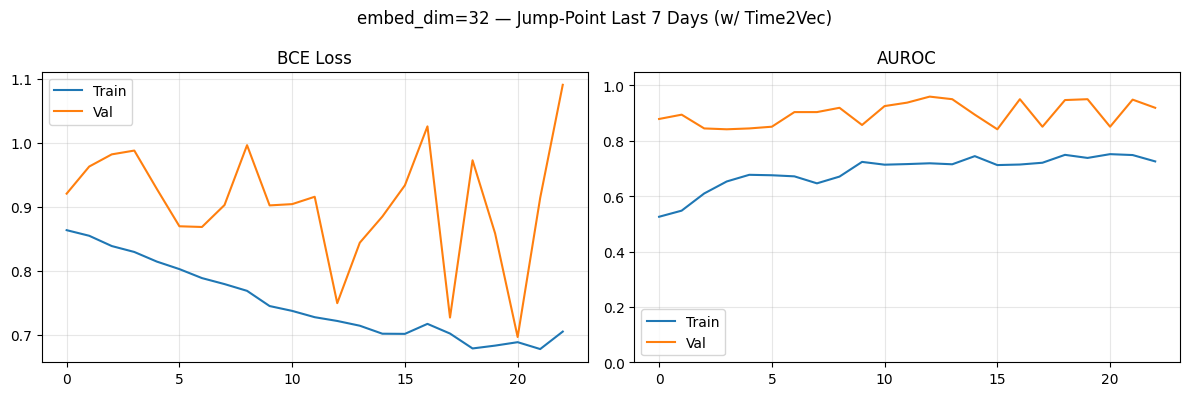

  Extracting embeddings (dim=32)...


    Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

  ✅ Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_32dim_withtime_jumppoint
     Train: (48, 34)  Val: (15, 34)  Test: (22, 34)

  EMBED_DIM = 64  |  nhead=4  |  hidden=256
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_64dim_withtime_jumppoint
  Parameters: 104,897

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


...

    Val  :   0%|          | 0/2 [00:00<?]

      20      0.6344     0.7532    0.8328   0.8913     1.7s  


    Train:   0%|          | 0/4 [00:00<?]

    Val  :   0%|          | 0/2 [00:00<?]

  Early stopping at epoch 21

  Best val AUROC (dim=64): 0.9503


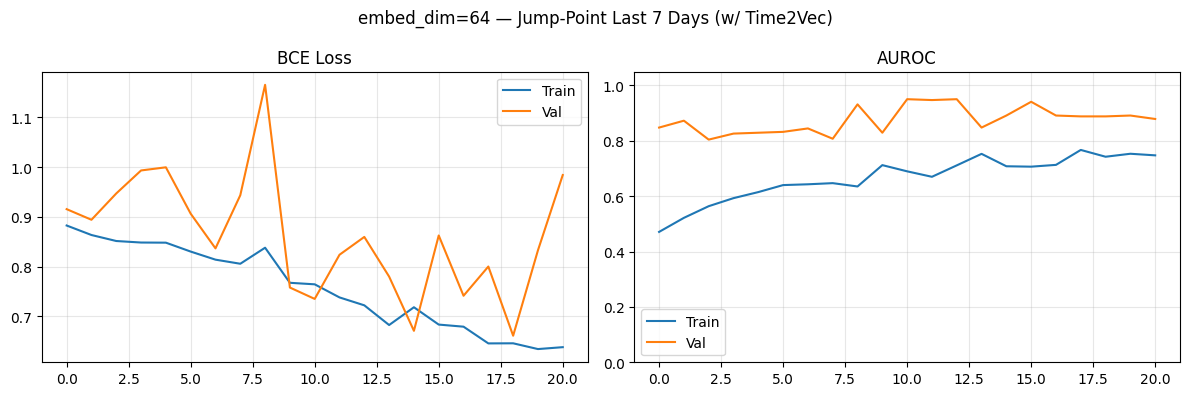

  Extracting embeddings (dim=64)...


    Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

  ✅ Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_64dim_withtime_jumppoint
     Train: (48, 66)  Val: (15, 66)  Test: (22, 66)

  EMBED_DIM = 128  |  nhead=4  |  hidden=512
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_128dim_withtime_jumppoint
  Parameters: 414,593

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


...

    Val  :   0%|          | 0/2 [00:00<?]

      20      0.3948     0.8854    1.3220   0.8820     2.0s  


    Train:   0%|          | 0/4 [00:00<?]

    Val  :   0%|          | 0/2 [00:00<?]

  Early stopping at epoch 21

  Best val AUROC (dim=128): 0.9348


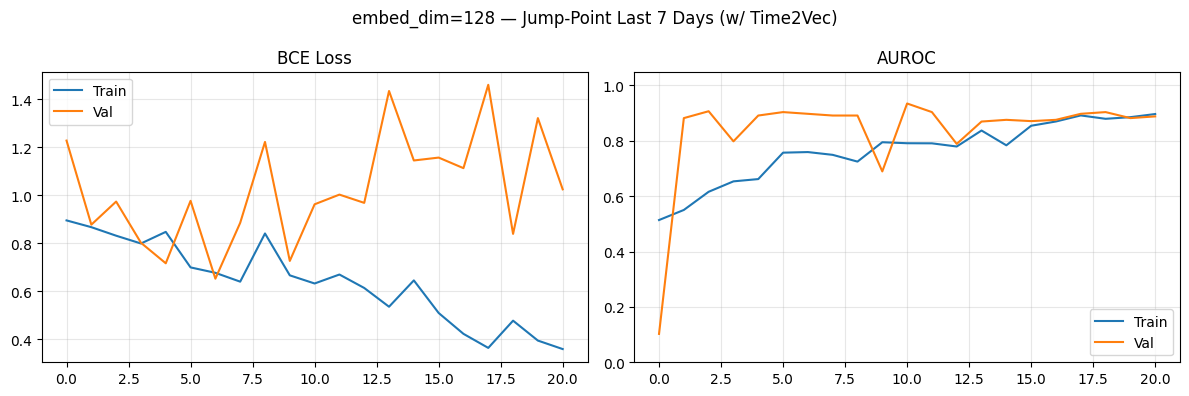

  Extracting embeddings (dim=128)...


    Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

    Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

  ✅ Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_128dim_withtime_jumppoint
     Train: (48, 130)  Val: (15, 130)  Test: (22, 130)

FINAL SUMMARY — Best Val AUROC per embed_dim (Jump-Point Last 7 Days, w/ Time2Vec)
  dim= 32: AUROC=0.9596  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_32dim_withtime_jumppoint
  dim= 64: AUROC=0.9503  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_64dim_withtime_jumppoint
  dim=128: AUROC=0.9348  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/jumppoint_embedding_classifier_128dim_withtime_jumppoint


In [10]:
DIM_CONFIGS = {
    32:  {'nhead': 4, 'hidden_dim': 128},
    64:  {'nhead': 4, 'hidden_dim': 256},
    128: {'nhead': 4, 'hidden_dim': 512},
}


def run_epoch(loader, model, optimizer, criterion, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []
    ctx  = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Val  '
    with ctx:
        pbar = tqdm(loader, desc=f'    {desc}', leave=False,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
        for batch in pbar:
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ts  = batch['timestamp'].to(device)
            pm  = batch['padding_mask'].to(device)
            lbl = batch['label'].to(device)
            with autocast():
                _, logit = model(tt, tv, ts, pm)
                loss = criterion(logit.squeeze(1), lbl)
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            total_loss += loss.item() * len(lbl)
            all_logits.append(logit.squeeze(1).detach().float().cpu())
            all_labels.append(lbl.cpu())
    all_logits = torch.cat(all_logits).sigmoid().numpy()
    all_labels = torch.cat(all_labels).numpy()
    avg_loss   = total_loss / len(all_labels)
    try:    auroc = roc_auc_score(all_labels, all_logits)
    except: auroc = float('nan')
    return avg_loss, auroc


def extract_embeddings(loader, model, device):
    """Returns one embedding per patient (mean of all chunks)."""
    accum = defaultdict(lambda: {'embs': [], 'label': None})
    with torch.no_grad():
        for batch in tqdm(loader, desc='    Extracting', leave=False):
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ts  = batch['timestamp'].to(device)
            pm  = batch['padding_mask'].to(device)
            with autocast():
                emb, _ = model(tt, tv, ts, pm)
            emb_np = emb.float().cpu().numpy()
            for j in range(len(batch['label'])):
                pid = batch['patient_id'][j]
                accum[pid]['embs'].append(emb_np[j])
                accum[pid]['label'] = int(batch['label'][j].item())
    records = []
    for pid, val in accum.items():
        mean_emb = np.mean(val['embs'], axis=0)
        row = {'patient_id': pid, 'label': val['label']}
        for k, v in enumerate(mean_emb):
            row[f'emb_{k}'] = float(v)
        records.append(row)
    return (pd.DataFrame(records)
              .sort_values('patient_id')
              .reset_index(drop=True))


# ── Main training loop ────────────────────────────────────────────────────────
all_dim_results = {}
NUM_EPOCHS     = 100
EARLY_STOP_PAT = 10

for EMBED_DIM, cfg in DIM_CONFIGS.items():
    print('\n' + '='*70)
    print(f'  EMBED_DIM = {EMBED_DIM}  |  nhead={cfg["nhead"]}  |  hidden={cfg["hidden_dim"]}')
    print('='*70)

    SAVE_DIR = os.path.join(
        BASE_SAVE,
        f'jumppoint_embedding_classifier_{EMBED_DIM}dim_withtime_jumppoint'
    )
    os.makedirs(SAVE_DIR, exist_ok=True)
    BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'best_jumppoint_transformer.pth')
    print(f'  Save dir: {SAVE_DIR}')

    model = JumpPointTransformer(
        vocab_size=VOCAB_SIZE, pad_type_id=PAD_TYPE_ID,
        embed_dim=EMBED_DIM, nhead=cfg['nhead'],
        num_layers=2, hidden_dim=cfg['hidden_dim'], dropout=0.2,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parameters: {n_params:,}')

    train_labels = [s[1] for s in train_ds.samples]
    n_pos = sum(train_labels); n_neg = len(train_labels) - n_pos
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10)
    scaler = GradScaler()

    best_val_auroc = 0.0
    early_stop_cnt = 0
    train_losses, val_losses, train_aurocs, val_aurocs = [], [], [], []

    print(f'\n  {"Epoch":>6}  {"Train Loss":>10}  {"Train AUC":>9}  '
          f'{"Val Loss":>8}  {"Val AUC":>7}  {"Time":>7}')
    print('  ' + '-'*62)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_auc = run_epoch(train_loader, model, optimizer,
                                    criterion, scaler, train=True)
        va_loss, va_auc = run_epoch(val_loader,   model, optimizer,
                                    criterion, scaler, train=False)
        elapsed = time.time() - t0

        train_losses.append(tr_loss); val_losses.append(va_loss)
        train_aurocs.append(tr_auc);  val_aurocs.append(va_auc)
        scheduler.step(va_auc if not np.isnan(va_auc) else 0.0)

        marker = ''
        if (not np.isnan(va_auc)) and va_auc > best_val_auroc:
            best_val_auroc = va_auc
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            early_stop_cnt = 0; marker = '✅'
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= EARLY_STOP_PAT:
                print(f'  Early stopping at epoch {epoch}'); break

        va_str = f'{va_auc:.4f}' if not np.isnan(va_auc) else '   nan'
        print(f'  {epoch:>6}  {tr_loss:>10.4f}  {tr_auc:>9.4f}  '
              f'{va_loss:>8.4f}  {va_str:>7}  {elapsed:>6.1f}s  {marker}')

    print(f'\n  Best val AUROC (dim={EMBED_DIM}): {best_val_auroc:.4f}')

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'embed_dim={EMBED_DIM} — Jump-Point Last 7 Days (w/ Time2Vec)', fontsize=12)
    axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Val')
    axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(train_aurocs, label='Train'); axes[1].plot(val_aurocs, label='Val')
    axes[1].set_title('AUROC'); axes[1].set_ylim(0, 1.05)
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
    plt.show()

    # Extract & save embeddings
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()
    print(f'  Extracting embeddings (dim={EMBED_DIM})...')
    emb_train = extract_embeddings(train_loader, model, device)
    emb_val   = extract_embeddings(val_loader,   model, device)
    emb_test  = extract_embeddings(test_loader,  model, device)

    emb_train.to_parquet(os.path.join(SAVE_DIR, 'emb_train.parquet'), index=False)
    emb_val.to_parquet(  os.path.join(SAVE_DIR, 'emb_val.parquet'),   index=False)
    emb_test.to_parquet( os.path.join(SAVE_DIR, 'emb_test.parquet'),  index=False)
    print(f'  ✅ Embeddings saved → {SAVE_DIR}')
    print(f'     Train: {emb_train.shape}  Val: {emb_val.shape}  Test: {emb_test.shape}')

    all_dim_results[EMBED_DIM] = {
        'best_val_auroc': best_val_auroc,
        'save_dir':  SAVE_DIR,
        'emb_train': emb_train,
        'emb_val':   emb_val,
        'emb_test':  emb_test,
    }
    del model; gc.collect(); torch.cuda.empty_cache()


print('\n' + '='*50)
print('FINAL SUMMARY — Best Val AUROC per embed_dim (Jump-Point Last 7 Days, w/ Time2Vec)')
print('='*50)
for dim, res in all_dim_results.items():
    print(f'  dim={dim:>3}: AUROC={res["best_val_auroc"]:.4f}  → {res["save_dir"]}')

---
## Step 10 — Verify Saved Embeddings

In [11]:
for dim in DIM_CONFIGS.keys():
    folder = os.path.join(BASE_SAVE,
                 f'jumppoint_embedding_classifier_{dim}dim_withtime_jumppoint')
    print(f'\ndim={dim}')
    for split in ['emb_train', 'emb_val', 'emb_test']:
        path = os.path.join(folder, f'{split}.parquet')
        if os.path.exists(path):
            tmp = pd.read_parquet(path)
            print(f'  ✅ {split}: {tmp.shape}  '
                  f'label0={(tmp["label"]==0).sum()}  '
                  f'label1={(tmp["label"]==1).sum()}')
        else:
            print(f'  ❌ MISSING: {path}')


dim=32
  ✅ emb_train: (48, 34)  label0=29  label1=19
  ✅ emb_val: (15, 34)  label0=10  label1=5
  ✅ emb_test: (22, 34)  label0=17  label1=5

dim=64
  ✅ emb_train: (48, 66)  label0=29  label1=19
  ✅ emb_val: (15, 66)  label0=10  label1=5
  ✅ emb_test: (22, 66)  label0=17  label1=5

dim=128
  ✅ emb_train: (48, 130)  label0=29  label1=19
  ✅ emb_val: (15, 130)  label0=10  label1=5
  ✅ emb_test: (22, 130)  label0=17  label1=5
